# Quadrant-Based Notifications — 4×4 Grid Over the Smell Report Area
### A finer-grained alternative to the 3-region approach

---

## The idea

Instead of three hand-drawn regions, we divide the area where people actually report smells into a **4×4 grid of 16 equal-sized quadrants**. Each quadrant gets its own independent pollution ranking — a quadrant only triggers a notification if the plume is in *that quadrant's own* top 10% of days, regardless of what's happening elsewhere.

## Why restrict to the smell-report area?

The raster covers a huge ~200km domain, but almost all of that is empty fields, forest, or areas with zero population density and zero app users. If we built a 4×4 grid over the *entire* raster, most quadrants would be meaningless — there's no one there to notify and no smell reports to validate against. So instead, we draw the grid only over the **bounding box of actual smell report locations** — the area where real people are actually reporting things. This keeps every quadrant relevant and testable.

## What this notebook does

1. Find the bounding box of all smell report locations
2. Divide that box into a 4×4 grid (16 quadrants)
3. For each day, compute each quadrant's pollution sum from the combined facility rasters
4. Rank days independently within each quadrant, set a per-quadrant top-10% threshold
5. Assign every smell report to its quadrant
6. Compute false positive / false negative **percentages** for each quadrant, with a clean copyable code block at the end

## Step 1 — Setup

In [1]:
# pip install rasterio numpy pandas matplotlib

import os
import glob
import warnings
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')
print('imports OK')

imports OK


## Step 2 — Configuration

In [2]:
# ── SETTINGS ──────────────────────────────────────────────────────────────────

FACILITY_DIRS = {
    'facility_A': '/Users/clairevlases/Desktop/mhci/create-lab/clairton',   # ← update these paths
    'facility_B': '/Users/clairevlases/Desktop/mhci/create-lab/edgar_thomson',
    'facility_C': '/Users/clairevlases/Desktop/create/irvin'
}

SMELL_REPORTS_CSV = './smell_reports.csv'
GLOBAL_RANKINGS_CSV = './daily_rankings.csv'  # output from the original ranking notebook

NODATA_VAL      = 0.0
MIN_SMELL_VALUE = 3       # only count smell reports rated 3-5
GRID_N          = 4       # 4x4 grid = 16 quadrants
TOP_FRACTION    = 0.10    # top 10% of days, computed separately per quadrant

# ──────────────────────────────────────────────────────────────────────────────
print('Config set')

Config set


## Step 3 — Find the bounding box of smell report locations

We load every smell report's lat/lon and take the min/max in each direction. This rectangle becomes the area we'll divide into quadrants — anywhere outside it gets ignored entirely, since there's no community data there to validate against.

In [3]:
raw_smell = pd.read_csv(SMELL_REPORTS_CSV)
filtered_smell = raw_smell[raw_smell['smell value'] >= MIN_SMELL_VALUE].copy()

lon_min = filtered_smell['skewed longitude'].min()
lon_max = filtered_smell['skewed longitude'].max()
lat_min = filtered_smell['skewed latitude'].min()
lat_max = filtered_smell['skewed latitude'].max()

print(f'Smell report bounding box:')
print(f'  Longitude: {lon_min:.4f} to {lon_max:.4f}')
print(f'  Latitude:  {lat_min:.4f} to {lat_max:.4f}')
print(f'  Width:     {lon_max - lon_min:.4f}°  (~{(lon_max-lon_min)*85:.1f} km)')
print(f'  Height:    {lat_max - lat_min:.4f}°  (~{(lat_max-lat_min)*111:.1f} km)')

Smell report bounding box:
  Longitude: -80.3002 to -79.7043
  Latitude:  40.2344 to 40.6729
  Width:     0.5959°  (~50.7 km)
  Height:    0.4385°  (~48.7 km)


## Step 4 — Build the 4×4 grid of quadrants

Divide the bounding box into equal-sized cells: `GRID_N` columns × `GRID_N` rows. Each quadrant gets an ID like `(0,0)` for the bottom-left, `(3,3)` for the top-right, etc. We store each quadrant's lon/lat boundaries so we can later check which raster pixels and which smell reports fall inside it.

In [4]:
lon_edges = np.linspace(lon_min, lon_max, GRID_N + 1)
lat_edges = np.linspace(lat_min, lat_max, GRID_N + 1)

quadrants = {}
for col in range(GRID_N):
    for row in range(GRID_N):
        qid = f'Q{row}_{col}'   # row = south-to-north index, col = west-to-east index
        quadrants[qid] = {
            'lon_min': lon_edges[col],
            'lon_max': lon_edges[col + 1],
            'lat_min': lat_edges[row],
            'lat_max': lat_edges[row + 1],
        }

print(f'Built {len(quadrants)} quadrants ({GRID_N}x{GRID_N} grid)')
print(f'\nExample — {list(quadrants.keys())[0]}:')
print(quadrants[list(quadrants.keys())[0]])

Built 16 quadrants (4x4 grid)

Example — Q0_0:
{'lon_min': np.float64(-80.3002243), 'lon_max': np.float64(-80.151245125), 'lat_min': np.float64(40.2343674), 'lat_max': np.float64(40.34398845)}


### Visualize the grid

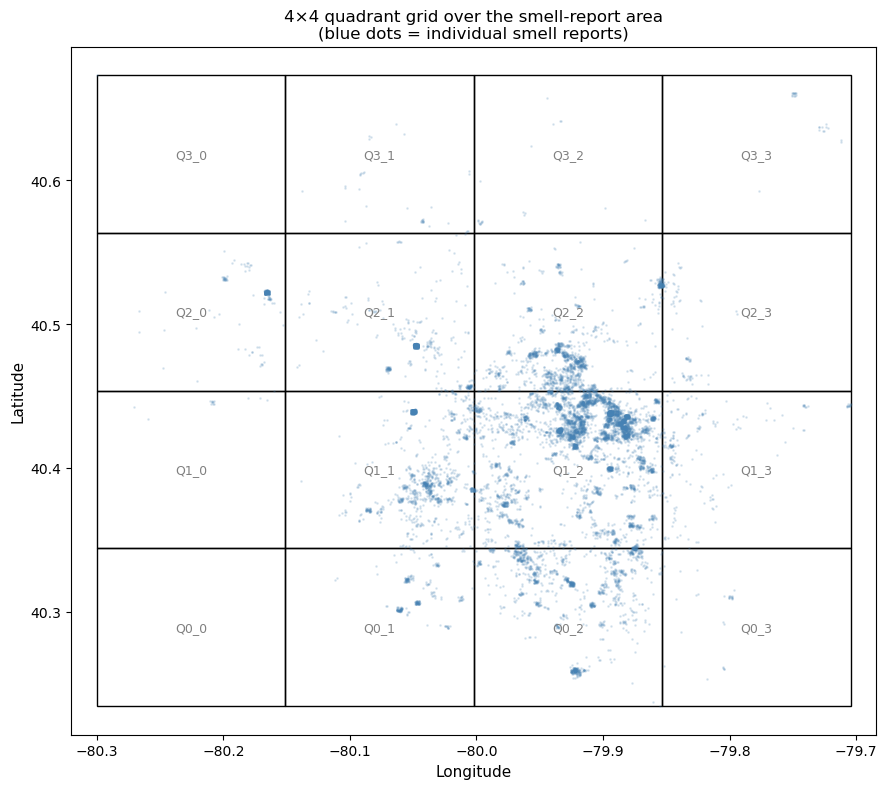

In [5]:
fig, ax = plt.subplots(figsize=(9, 8))

for qid, bounds in quadrants.items():
    rect = mpatches.Rectangle(
        (bounds['lon_min'], bounds['lat_min']),
        bounds['lon_max'] - bounds['lon_min'],
        bounds['lat_max'] - bounds['lat_min'],
        facecolor='none', edgecolor='black', linewidth=1
    )
    ax.add_patch(rect)
    cx = (bounds['lon_min'] + bounds['lon_max']) / 2
    cy = (bounds['lat_min'] + bounds['lat_max']) / 2
    ax.text(cx, cy, qid, ha='center', va='center', fontsize=9, color='grey')

# Overlay smell report points for reference
ax.scatter(filtered_smell['skewed longitude'], filtered_smell['skewed latitude'],
           s=1, alpha=0.15, color='steelblue')

ax.set_xlim(lon_min - 0.02, lon_max + 0.02)
ax.set_ylim(lat_min - 0.02, lat_max + 0.02)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title(f'{GRID_N}×{GRID_N} quadrant grid over the smell-report area\n'
             f'(blue dots = individual smell reports)', fontsize=12)
plt.tight_layout()
plt.savefig('quadrant_grid.png', dpi=130, bbox_inches='tight')
plt.show()

## Step 5 — Combine facility rasters

Same as in previous notebooks: load each facility's TIF for a day and sum them. This assumes the facilities are on the same grid (same bounds). If yours are offset, swap in the pixel-offset stitching version from the day-ranking notebook.

In [6]:
def combine_facilities(date_str, facility_dirs, nodata=0.0):
    combined = None
    meta = None
    sources = []
    for name, folder in facility_dirs.items():
        fpath = os.path.join(folder, f'{date_str}.tif')
        if not os.path.exists(fpath):
            continue
        with rasterio.open(fpath) as src:
            data = src.read(1).astype(np.float32)
            if meta is None:
                meta = src.meta.copy()
                combined = np.zeros_like(data)
        data[data == nodata] = 0.0
        combined += data
        sources.append(name)
    return combined, meta, sources


all_dates = set()
for name, folder in FACILITY_DIRS.items():
    files = glob.glob(os.path.join(folder, '*.tif'))
    all_dates |= {os.path.basename(f).replace('.tif', '') for f in files}
all_dates = sorted(all_dates)
print(f'Total dates available: {len(all_dates)}')

test_arr, test_meta, test_sources = combine_facilities(all_dates[0], FACILITY_DIRS)
print(f'Test combine: {all_dates[0]}, facilities: {test_sources}, shape: {test_arr.shape}')

Total dates available: 366
Test combine: 20240101, facilities: ['facility_A', 'facility_B', 'facility_C'], shape: (601, 601)


## Step 6 — Build a pixel mask for each quadrant

For each of the 16 quadrants, figure out which raster pixels fall inside its lon/lat box. We use the raster's affine transform to convert each quadrant's corner coordinates into pixel row/column indices, then build a boolean mask the same shape as the raster (`True` = inside this quadrant).

In [7]:
def build_quadrant_masks(quadrants, transform, shape):
    """
    For each quadrant's lon/lat box, build a boolean mask over the raster grid.
    Uses rasterio's ~transform (inverse) to convert geographic coordinates
    directly into pixel row/column indices.
    """
    masks = {}
    inv_transform = ~transform   # inverse: geographic coords -> pixel coords

    for qid, bounds in quadrants.items():
        # Convert all four corners to pixel space to find the row/col range
        col_min_f, row_max_f = inv_transform * (bounds['lon_min'], bounds['lat_min'])
        col_max_f, row_min_f = inv_transform * (bounds['lon_max'], bounds['lat_max'])

        col_lo, col_hi = sorted([int(np.floor(col_min_f)), int(np.ceil(col_max_f))])
        row_lo, row_hi = sorted([int(np.floor(row_min_f)), int(np.ceil(row_max_f))])

        # Clip to raster bounds
        col_lo, col_hi = max(0, col_lo), min(shape[1], col_hi)
        row_lo, row_hi = max(0, row_lo), min(shape[0], row_hi)

        mask = np.zeros(shape, dtype=bool)
        mask[row_lo:row_hi, col_lo:col_hi] = True
        masks[qid] = mask

    return masks


quadrant_masks = build_quadrant_masks(quadrants, test_meta['transform'], test_arr.shape)

print('Quadrant masks built:')
for qid, mask in quadrant_masks.items():
    print(f'  {qid}: {mask.sum():,} pixels')

Quadrant masks built:
  Q0_0: 1,530 pixels
  Q1_0: 1,530 pixels
  Q2_0: 1,530 pixels
  Q3_0: 1,530 pixels
  Q0_1: 1,564 pixels
  Q1_1: 1,564 pixels
  Q2_1: 1,564 pixels
  Q3_1: 1,564 pixels
  Q0_2: 1,564 pixels
  Q1_2: 1,564 pixels
  Q2_2: 1,564 pixels
  Q3_2: 1,564 pixels
  Q0_3: 1,564 pixels
  Q1_3: 1,564 pixels
  Q2_3: 1,564 pixels
  Q3_3: 1,564 pixels


### Visual check — masks should tile into a clean 4×4 grid

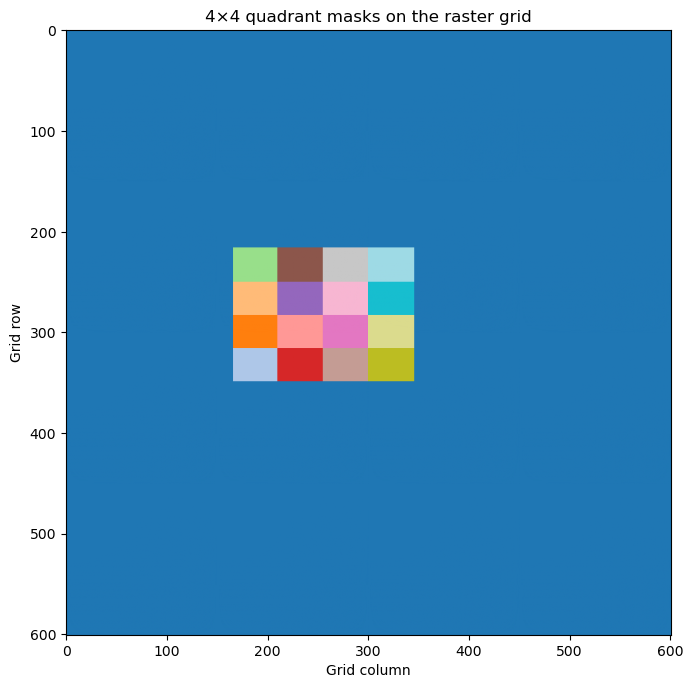

In [8]:
combined_mask_view = np.zeros(test_arr.shape, dtype=int)
for i, (qid, mask) in enumerate(quadrant_masks.items()):
    combined_mask_view[mask] = i + 1

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(combined_mask_view, cmap='tab20', origin='upper')
ax.set_title(f'{GRID_N}×{GRID_N} quadrant masks on the raster grid', fontsize=12)
ax.set_xlabel('Grid column'); ax.set_ylabel('Grid row')
plt.tight_layout()
plt.savefig('quadrant_masks_check.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 7 — Compute each quadrant's pollution sum for every day

In [9]:
import time

# Test 1: how long does combine_facilities take alone?
t0 = time.time()
test_combined, test_meta, test_sources = combine_facilities(all_dates[0], FACILITY_DIRS)
print(f'combine_facilities: {time.time()-t0:.3f}s')

# Test 2: how long does masking all 16 quadrants take?
t0 = time.time()
for qid, mask in quadrant_masks.items():
    masked = test_combined * mask
    s = masked.sum()
    m = masked.max()
    nz = (masked > 0).sum()
print(f'Masking all 16 quadrants: {time.time()-t0:.4f}s')

# Test 3: how many quadrant_masks actually exist?
print(f'Number of quadrant masks: {len(quadrant_masks)}')

# Test 4: how many dates?
print(f'Number of dates: {len(all_dates)}')

combine_facilities: 0.008s
Masking all 16 quadrants: 0.0068s
Number of quadrant masks: 16
Number of dates: 366


In [10]:
import sys
print(f'Size of quadrant_masks in memory: {sum(m.nbytes for m in quadrant_masks.values()) / 1e6:.2f} MB')

Size of quadrant_masks in memory: 5.78 MB


In [11]:
import os

print(f'Date range check:')
print(f'First date: {all_dates[0]}, Last date: {all_dates[-1]}')
print(f'Total: {len(all_dates)}')

# Check file sizes — are any TIFs unusually large?
for name, folder in FACILITY_DIRS.items():
    files = [f for f in os.listdir(folder) if f.endswith('.tif')]
    sizes = [os.path.getsize(os.path.join(folder, f)) for f in files]
    print(f'\n{name}: {len(files)} files')
    print(f'  Min size: {min(sizes)/1024:.1f} KB')
    print(f'  Max size: {max(sizes)/1024:.1f} KB')
    print(f'  Avg size: {sum(sizes)/len(sizes)/1024:.1f} KB')

Date range check:
First date: 20240101, Last date: 20241231
Total: 366

facility_A: 366 files
  Min size: 90.0 KB
  Max size: 387.6 KB
  Avg size: 195.9 KB

facility_B: 366 files
  Min size: 86.6 KB
  Max size: 394.2 KB
  Avg size: 193.5 KB

facility_C: 366 files
  Min size: 90.3 KB
  Max size: 407.5 KB
  Avg size: 195.2 KB


In [12]:
print(FACILITY_DIRS)
print(f'Number of facilities: {len(FACILITY_DIRS)}')

{'facility_A': '/Users/clairevlases/Desktop/mhci/create-lab/clairton', 'facility_B': '/Users/clairevlases/Desktop/mhci/create-lab/edgar_thomson', 'facility_C': '/Users/clairevlases/Desktop/create/irvin'}
Number of facilities: 3


In [13]:
import time

t_start = time.time()
times = []

for i, date_str in enumerate(all_dates[:20]):
    t0 = time.time()
    combined, meta, sources = combine_facilities(date_str, FACILITY_DIRS)
    if combined is not None:
        for qid, mask in quadrant_masks.items():
            masked = combined * mask
            s = masked.sum()
    elapsed = time.time() - t0
    times.append(elapsed)
    print(f'{date_str}: {elapsed:.3f}s, facilities found: {sources}')

print(f'\nTotal for 20 days: {time.time()-t_start:.2f}s')
print(f'First 5 avg: {sum(times[:5])/5:.3f}s, Last 5 avg: {sum(times[-5:])/5:.3f}s')

20240101: 0.026s, facilities found: ['facility_A', 'facility_B', 'facility_C']
20240102: 0.015s, facilities found: ['facility_A', 'facility_B', 'facility_C']
20240103: 0.010s, facilities found: ['facility_A', 'facility_B', 'facility_C']
20240104: 0.011s, facilities found: ['facility_A', 'facility_B', 'facility_C']
20240105: 0.011s, facilities found: ['facility_A', 'facility_B', 'facility_C']
20240106: 0.013s, facilities found: ['facility_A', 'facility_B', 'facility_C']
20240107: 0.009s, facilities found: ['facility_A', 'facility_B', 'facility_C']
20240108: 0.013s, facilities found: ['facility_A', 'facility_B', 'facility_C']
20240109: 0.012s, facilities found: ['facility_A', 'facility_B', 'facility_C']
20240110: 0.010s, facilities found: ['facility_A', 'facility_B', 'facility_C']
20240111: 0.011s, facilities found: ['facility_A', 'facility_B', 'facility_C']
20240112: 0.011s, facilities found: ['facility_A', 'facility_B', 'facility_C']
20240113: 0.010s, facilities found: ['facility_A', '

In [16]:
import time
print(f'CELL START: {time.strftime("%H:%M:%S")}')

records = []
for date_str in all_dates:
    combined, meta, sources = combine_facilities(date_str, FACILITY_DIRS)
    if combined is None:
        continue
    row = {'date': pd.to_datetime(date_str, format='%Y%m%d'), 'date_str': date_str,
           'facilities': ', '.join(sources)}
    for qid, mask in quadrant_masks.items():
        masked = combined * mask
        row[f'sum_{qid}'] = float(masked.sum())
        row[f'max_{qid}'] = float(masked.max())
        row[f'nonzero_{qid}'] = int((masked > 0).sum())
    records.append(row)

daily_quadrant = pd.DataFrame(records).sort_values('date').reset_index(drop=True)
print(f'CELL END: {time.strftime("%H:%M:%S")}')
print(f'Processed {len(daily_quadrant)} days')





CELL START: 15:22:51
CELL END: 15:23:55
Processed 366 days


## Step 8 — Rank days independently within each quadrant

Each quadrant gets its own threshold based only on its own history. Quadrants with very little pollution exposure (far from any facility) will have low thresholds; quadrants near the plant will have higher ones — but each is "top 10% for that specific area."

In [17]:
quadrant_thresholds = {}

for qid in quadrant_masks.keys():
    sum_col = f'sum_{qid}'
    threshold = daily_quadrant[sum_col].quantile(1 - TOP_FRACTION)
    quadrant_thresholds[qid] = threshold

    daily_quadrant[f'rank_{qid}']   = daily_quadrant[sum_col].rank(ascending=False, method='min').astype(int)
    daily_quadrant[f'notify_{qid}'] = daily_quadrant[sum_col] >= threshold

print('Per-quadrant thresholds and notification counts:')
for qid, t in quadrant_thresholds.items():
    n_notify = daily_quadrant[f'notify_{qid}'].sum()
    print(f'  {qid}: threshold={t:8.1f}  notify_days={n_notify}')

Per-quadrant thresholds and notification counts:
  Q0_0: threshold=   286.1  notify_days=37
  Q1_0: threshold=   382.5  notify_days=37
  Q2_0: threshold=   316.9  notify_days=37
  Q3_0: threshold=   306.2  notify_days=37
  Q0_1: threshold=   543.8  notify_days=37
  Q1_1: threshold=   956.7  notify_days=37
  Q2_1: threshold=   993.7  notify_days=37
  Q3_1: threshold=   428.2  notify_days=37
  Q0_2: threshold=  1298.8  notify_days=37
  Q1_2: threshold=  5125.5  notify_days=37
  Q2_2: threshold=  1987.0  notify_days=37
  Q3_2: threshold=   512.6  notify_days=37
  Q0_3: threshold=  1309.6  notify_days=37
  Q1_3: threshold=  4546.5  notify_days=37
  Q2_3: threshold=  1521.6  notify_days=37
  Q3_3: threshold=   715.5  notify_days=37


## Step 9 — Assign smell reports to a quadrant

For every report, check which quadrant's lon/lat box contains it — straightforward comparison since quadrants are simple rectangles (no need for full polygon geometry like the 3-region notebook).

In [18]:
def assign_quadrant(lon, lat, quadrants):
    for qid, b in quadrants.items():
        if b['lon_min'] <= lon < b['lon_max'] and b['lat_min'] <= lat < b['lat_max']:
            return qid
    return None  # falls exactly on the outer edge or outside — shouldn't happen often

filtered_smell['quadrant'] = filtered_smell.apply(
    lambda r: assign_quadrant(r['skewed longitude'], r['skewed latitude'], quadrants),
    axis=1
)

n_assigned = filtered_smell['quadrant'].notna().sum()
print(f'Reports assigned to a quadrant: {n_assigned:,} / {len(filtered_smell):,}')
print(f'\nReports per quadrant:')
print(filtered_smell['quadrant'].value_counts().sort_index().to_string())

Reports assigned to a quadrant: 10,592 / 10,594

Reports per quadrant:
quadrant
Q0_1     232
Q0_2    1206
Q0_3      28
Q1_0      15
Q1_1    1143
Q1_2    5414
Q1_3     194
Q2_0     224
Q2_1     555
Q2_2    1401
Q2_3     100
Q3_1      35
Q3_2      20
Q3_3      25


## Step 10 — Aggregate smell reports to daily counts, per quadrant

In [19]:
filtered_smell['date'] = pd.to_datetime(
    filtered_smell['date & time'].str[:10], format='%m/%d/%Y'
)
filtered_smell['date_str'] = filtered_smell['date'].dt.strftime('%Y%m%d')

smell_with_quadrant = filtered_smell.dropna(subset=['quadrant'])

smell_daily_by_quadrant = (
    smell_with_quadrant.groupby(['date_str', 'quadrant'])
    .agg(n_reports=('smell value', 'count'), mean_smell=('smell value', 'mean'))
    .reset_index()
)

print(f'Daily quadrant smell records: {len(smell_daily_by_quadrant)}')
print(smell_daily_by_quadrant.head(10).to_string(index=False))

Daily quadrant smell records: 1985
date_str quadrant  n_reports  mean_smell
20240101     Q2_0          1         5.0
20240101     Q2_1          2         4.0
20240102     Q0_1          1         3.0
20240102     Q1_2          5         4.0
20240102     Q1_3          1         3.0
20240102     Q2_0          1         3.0
20240103     Q0_2          1         3.0
20240104     Q0_1          1         3.0
20240104     Q2_0          1         4.0
20240105     Q0_1          1         3.0


## Step 11 — Merge quadrant plume data with quadrant smell data

Reshape the wide quadrant table (one row per day, 16 columns) into a long table (one row per day × quadrant), then merge with the smell data on (date, quadrant).

In [20]:
qids = list(quadrant_masks.keys())

long_rows = []
for _, row in daily_quadrant.iterrows():
    for qid in qids:
        long_rows.append({
            'date_str':     row['date_str'],
            'quadrant':     qid,
            'regional_sum': row[f'sum_{qid}'],
            'regional_max': row[f'max_{qid}'],
            'rank':          row[f'rank_{qid}'],
            'notify':        row[f'notify_{qid}'],
        })
quadrant_long = pd.DataFrame(long_rows)

quadrant_merged = quadrant_long.merge(
    smell_daily_by_quadrant, left_on=['date_str', 'quadrant'],
    right_on=['date_str', 'quadrant'], how='left'
)
quadrant_merged['n_reports']  = quadrant_merged['n_reports'].fillna(0).astype(int)
quadrant_merged['mean_smell'] = quadrant_merged['mean_smell'].fillna(0)

print(f'Combined quadrant-day table: {len(quadrant_merged)} rows '
      f'({len(daily_quadrant)} days × {len(qids)} quadrants)')
print(quadrant_merged.head(8).to_string(index=False))

Combined quadrant-day table: 5856 rows (366 days × 16 quadrants)
date_str quadrant  regional_sum  regional_max  rank  notify  n_reports  mean_smell
20240101     Q0_0           0.0           0.0   150   False          0         0.0
20240101     Q1_0           0.0           0.0   169   False          0         0.0
20240101     Q2_0           0.0           0.0   185   False          1         5.0
20240101     Q3_0           0.0           0.0   195   False          0         0.0
20240101     Q0_1           0.0           0.0   178   False          0         0.0
20240101     Q1_1           0.0           0.0   219   False          0         0.0
20240101     Q2_1           0.0           0.0   226   False          2         4.0
20240101     Q3_1           0.0           0.0   219   False          0         0.0


## Step 12 — False positive / false negative rates, per quadrant

For each quadrant we define "smell high" as that quadrant's own top 25% of report days. Then:

- **False positive rate** = of all days the quadrant did NOT have a high-smell day, what % did the model still notify?
- **False negative rate** = of all days the quadrant DID have a high-smell day, what % did the model fail to notify?

These are expressed as percentages (not raw counts) so quadrants with very few smell reports are still comparable to ones with many.

In [21]:
# ── COPYABLE BLOCK: FP/FN rates per quadrant ──────────────────────────────────

fp_fn_rows = []

for qid in qids:
    sub = quadrant_merged[quadrant_merged['quadrant'] == qid].copy()

    # Skip quadrants with too few reports to compute a meaningful threshold
    if sub['n_reports'].sum() == 0:
        continue

    smell_high_threshold = sub['n_reports'].quantile(0.75)
    sub['smell_high'] = sub['n_reports'] >= smell_high_threshold

    true_pos  = ((sub['notify'])  & (sub['smell_high'])).sum()
    false_pos = ((sub['notify'])  & (~sub['smell_high'])).sum()
    false_neg = ((~sub['notify']) & (sub['smell_high'])).sum()
    true_neg  = ((~sub['notify']) & (~sub['smell_high'])).sum()

    n_notify_days   = sub['notify'].sum()
    n_quiet_days    = (~sub['notify']).sum()
    n_smell_high    = sub['smell_high'].sum()
    n_smell_low     = (~sub['smell_high']).sum()

    # False positive rate: of days the model notified, what % were NOT actually high-smell
    fp_rate = (false_pos / n_notify_days * 100) if n_notify_days > 0 else np.nan

    # False negative rate: of days that WERE high-smell, what % did the model miss
    fn_rate = (false_neg / n_smell_high * 100) if n_smell_high > 0 else np.nan

    fp_fn_rows.append({
        'quadrant': qid,
        'n_reports_total': sub['n_reports'].sum(),
        'smell_high_threshold': round(smell_high_threshold, 1),
        'true_positives': true_pos,
        'false_positives': false_pos,
        'false_negatives': false_neg,
        'true_negatives': true_neg,
        'false_positive_rate_%': round(fp_rate, 1) if not np.isnan(fp_rate) else None,
        'false_negative_rate_%': round(fn_rate, 1) if not np.isnan(fn_rate) else None,
    })

fp_fn_summary = pd.DataFrame(fp_fn_rows)
print(fp_fn_summary.to_string(index=False))

# ───────────────────────────────────────────────────────────────────────────

quadrant  n_reports_total  smell_high_threshold  true_positives  false_positives  false_negatives  true_negatives  false_positive_rate_%  false_negative_rate_%
    Q1_0               15                   0.0              37                0              329               0                    0.0                   89.9
    Q2_0              224                   1.0              19               18              156             173                   48.6                   89.1
    Q0_1              232                   1.0              24               13               88             241                   35.1                   78.6
    Q1_1             1143                   4.0              20               17               77             252                   45.9                   79.4
    Q2_1              555                   2.0              22               15              125             204                   40.5                   85.0
    Q3_1               35               

### Visualizing FP/FN rates by quadrant

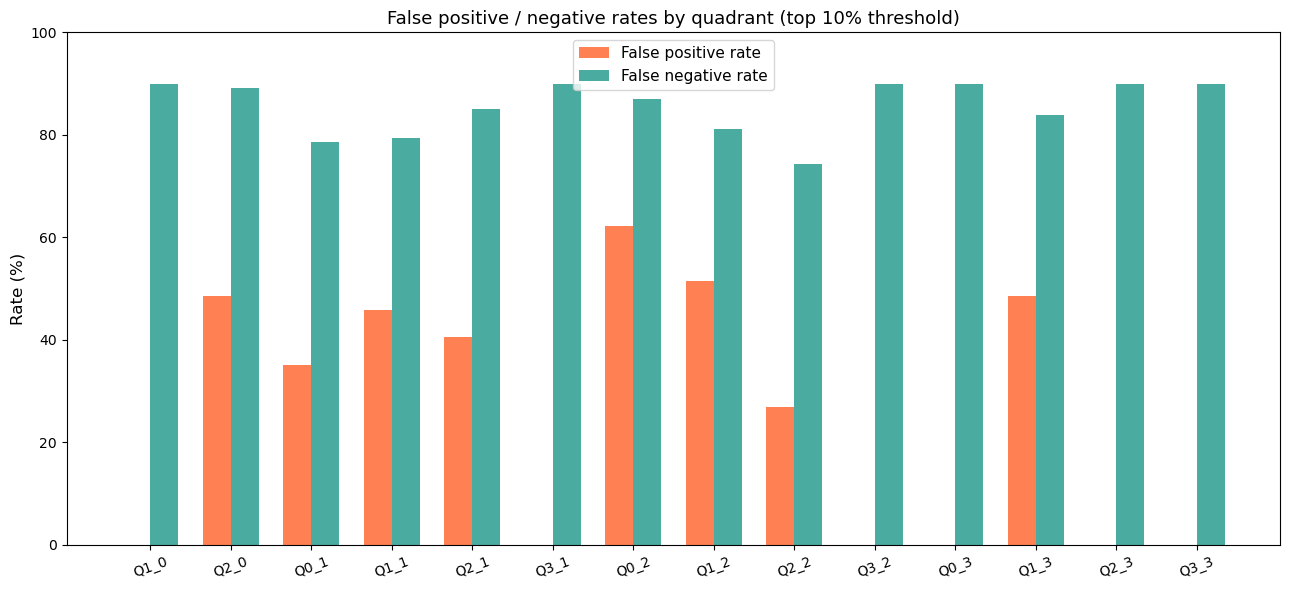

In [22]:
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(fp_fn_summary))
width = 0.35

ax.bar(x - width/2, fp_fn_summary['false_positive_rate_%'], width,
       label='False positive rate', color='#FF6B35', alpha=0.85)
ax.bar(x + width/2, fp_fn_summary['false_negative_rate_%'], width,
       label='False negative rate', color='#2A9D8F', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(fp_fn_summary['quadrant'], fontsize=10, rotation=20)
ax.set_ylabel('Rate (%)', fontsize=12)
ax.set_title(f'False positive / negative rates by quadrant (top {TOP_FRACTION*100:.0f}% threshold)',
             fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('quadrant_fp_fn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 13 — Compare against the old global approach

Load the original global daily rankings and compute the same FP/FN rates as if the *entire region* used a single threshold — but evaluated against each quadrant's own smell data. This shows directly whether quadrant-level notification is actually an improvement over the global approach.

In [23]:
global_daily = pd.read_csv(GLOBAL_RANKINGS_CSV)
global_daily['date_str'] = pd.to_datetime(global_daily['date']).dt.strftime('%Y%m%d')
global_threshold = global_daily['regional_sum'].quantile(1 - TOP_FRACTION)
global_daily['notify_global'] = global_daily['regional_sum'] >= global_threshold

quadrant_merged = quadrant_merged.merge(
    global_daily[['date_str', 'notify_global']], on='date_str', how='left'
)
quadrant_merged['notify_global'] = quadrant_merged['notify_global'].fillna(False)

global_fp_fn_rows = []
for qid in qids:
    sub = quadrant_merged[quadrant_merged['quadrant'] == qid].copy()
    if sub['n_reports'].sum() == 0:
        continue

    smell_high_threshold = sub['n_reports'].quantile(0.75)
    sub['smell_high'] = sub['n_reports'] >= smell_high_threshold

    false_pos = ((sub['notify_global'])  & (~sub['smell_high'])).sum()
    false_neg = ((~sub['notify_global']) & (sub['smell_high'])).sum()
    n_notify_days = sub['notify_global'].sum()
    n_smell_high  = sub['smell_high'].sum()

    fp_rate = (false_pos / n_notify_days * 100) if n_notify_days > 0 else np.nan
    fn_rate = (false_neg / n_smell_high * 100) if n_smell_high > 0 else np.nan

    global_fp_fn_rows.append({
        'quadrant': qid,
        'global_false_positive_rate_%': round(fp_rate, 1) if not np.isnan(fp_rate) else None,
        'global_false_negative_rate_%': round(fn_rate, 1) if not np.isnan(fn_rate) else None,
    })

global_fp_fn = pd.DataFrame(global_fp_fn_rows)
comparison = fp_fn_summary.merge(global_fp_fn, on='quadrant')

print(comparison[['quadrant', 'false_positive_rate_%', 'global_false_positive_rate_%',
                  'false_negative_rate_%', 'global_false_negative_rate_%']].to_string(index=False))

quadrant  false_positive_rate_%  global_false_positive_rate_%  false_negative_rate_%  global_false_negative_rate_%
    Q1_0                    0.0                           0.0                   89.9                          89.9
    Q2_0                   48.6                          51.4                   89.1                          89.7
    Q0_1                   35.1                          48.6                   78.6                          83.0
    Q1_1                   45.9                          43.2                   79.4                          78.4
    Q2_1                   40.5                          45.9                   85.0                          86.4
    Q3_1                    0.0                           0.0                   89.9                          89.9
    Q0_2                   62.2                          43.2                   87.0                          80.6
    Q1_2                   51.4                          56.8                   

In [25]:
for qid in ['Q1_0', 'Q3_1', 'Q3_2', 'Q0_3', 'Q2_3', 'Q3_3']:
    sub = quadrant_merged[quadrant_merged['quadrant'] == qid]
    print(f"{qid}: notify_days={sub['notify'].sum()}, total_reports={sub['n_reports'].sum()}, "
          f"n_reports stats: min={sub['n_reports'].min()}, max={sub['n_reports'].max()}, "
          f"75th pct threshold={sub['n_reports'].quantile(0.75):.1f}")

Q1_0: notify_days=37, total_reports=15, n_reports stats: min=0, max=1, 75th pct threshold=0.0
Q3_1: notify_days=37, total_reports=35, n_reports stats: min=0, max=2, 75th pct threshold=0.0
Q3_2: notify_days=37, total_reports=20, n_reports stats: min=0, max=2, 75th pct threshold=0.0
Q0_3: notify_days=37, total_reports=28, n_reports stats: min=0, max=2, 75th pct threshold=0.0
Q2_3: notify_days=37, total_reports=100, n_reports stats: min=0, max=4, 75th pct threshold=0.0
Q3_3: notify_days=37, total_reports=25, n_reports stats: min=0, max=3, 75th pct threshold=0.0


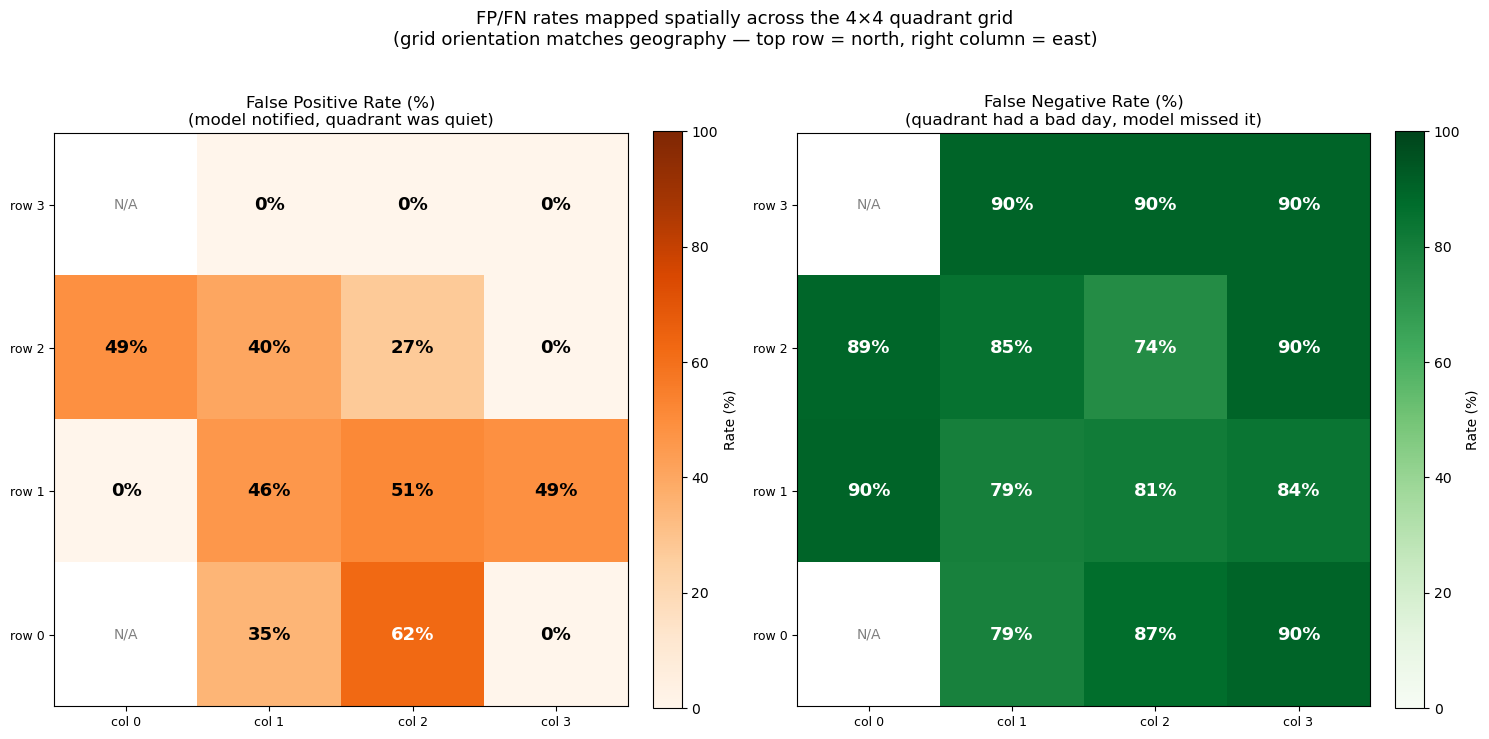

In [24]:
# ── SPATIAL HEATMAP: FP/FN rates laid out on the actual quadrant grid ────────

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Build a GRID_N x GRID_N array for each metric, indexed by (row, col)
fp_grid = np.full((GRID_N, GRID_N), np.nan)
fn_grid = np.full((GRID_N, GRID_N), np.nan)

for _, r in fp_fn_summary.iterrows():
    qid = r['quadrant']
    row_idx = int(qid.split('_')[0][1:])   # 'Q1_2' -> row=1
    col_idx = int(qid.split('_')[1])       # 'Q1_2' -> col=2
    fp_grid[row_idx, col_idx] = r['false_positive_rate_%']
    fn_grid[row_idx, col_idx] = r['false_negative_rate_%']

# Flip vertically so row 0 (southernmost) is at the bottom, matching the map
fp_grid_display = np.flipud(fp_grid)
fn_grid_display = np.flipud(fn_grid)

for ax, grid, title, cmap in zip(
    axes,
    [fp_grid_display, fn_grid_display],
    ['False Positive Rate (%)\n(model notified, quadrant was quiet)',
     'False Negative Rate (%)\n(quadrant had a bad day, model missed it)'],
    ['Oranges', 'Greens']
):
    im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=100)

    # Annotate each cell with its value
    for row in range(GRID_N):
        for col in range(GRID_N):
            val = grid[row, col]
            if not np.isnan(val):
                text_color = 'white' if val > 55 else 'black'
                ax.text(col, row, f'{val:.0f}%', ha='center', va='center',
                        fontsize=13, fontweight='bold', color=text_color)
            else:
                ax.text(col, row, 'N/A', ha='center', va='center',
                        fontsize=10, color='grey')

    ax.set_xticks(range(GRID_N))
    ax.set_yticks(range(GRID_N))
    ax.set_xticklabels([f'col {c}' for c in range(GRID_N)], fontsize=9)
    ax.set_yticklabels([f'row {GRID_N-1-r}' for r in range(GRID_N)], fontsize=9)
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, label='Rate (%)', fraction=0.046, pad=0.04)

plt.suptitle('FP/FN rates mapped spatially across the 4×4 quadrant grid\n'
             '(grid orientation matches geography — top row = north, right column = east)',
             fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig('quadrant_fp_fn_spatial_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Save outputs

In [ ]:
daily_quadrant.to_csv('daily_quadrant_sums.csv', index=False)
quadrant_merged.to_csv('quadrant_smell_plume_merged.csv', index=False)
comparison.to_csv('quadrant_vs_global_fp_fn.csv', index=False)

print('Saved:')
print('  daily_quadrant_sums.csv          — one row per day, sum/max/nonzero per quadrant')
print('  quadrant_smell_plume_merged.csv  — one row per day x quadrant, plume + smell + notify flags')
print('  quadrant_vs_global_fp_fn.csv     — FP/FN rate comparison, quadrant vs. global')